# Graph Analytics — Industri × Region Clustering (v2: dengan cross-segment edges)
### Capstone Project: Screening Credit Agentic AI for eLO System

**Perubahan dari versi sebelumnya:** versi awal hanya membuat edge di dalam kombinasi
`sub_industry|region` yang sama persis — hasilnya 80 cluster yang **terisolasi total** satu sama lain
(0 edge lintas cluster), sehingga visualisasinya cuma bubble chart tanpa connector, bukan graph
sungguhan.

Versi ini menambahkan **edge kedua**: dua nasabah terhubung juga kalau `risk_score` mereka mirip,
**walaupun beda `sub_industry`/`region`**. Ini menghasilkan cluster yang bisa memotong batas
segmen — insight barunya: segmen mana yang "menyatu" secara risiko meski industrinya beda.

**Alur (Tahap 0–7):**
0. Load & validasi data
1. Bangun bipartite graph (dalam-segmen) + KNN graph (lintas-segmen berbasis risk_score)
2. Gabungkan jadi satu graph nasabah-nasabah berbobot
3. Community detection (Louvain) — sekarang bisa mixed-segment
4. Metrik risiko per cluster
5. Centrality — nasabah representatif per cluster
6. Visualisasi graph di level cluster **dengan connector antar cluster**
7. Insight/narasi otomatis, termasuk pasangan cluster yang paling erat terhubung

## Tahap 0 — Setup & Load Data

Catatan penanganan data (sama seperti versi sebelumnya):
- Kolom skor: **`risk_score`** (higher = better)
- 220 baris `risk_score` NaN = kasus hard-reject (DHN/SLIK buruk) → diisi `0.0`
- `sub_industry × region` = 80 kombinasi unik

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from networkx.algorithms import bipartite
from collections import defaultdict

try:
    from networkx.algorithms.community import louvain_communities
    HAVE_NX_LOUVAIN = True
except ImportError:
    HAVE_NX_LOUVAIN = False

try:
    import community as community_louvain
    HAVE_PY_LOUVAIN = True
except ImportError:
    HAVE_PY_LOUVAIN = False

import matplotlib.pyplot as plt
import matplotlib.cm as cm

pd.set_option("display.max_columns", 50)
np.random.seed(42)

In [2]:
DATA_PATH = "../data/processed/master_scored.csv"

COL = {
    "id": "NIK",
    "industri": "industry",
    "sub_industri": "sub_industry",
    "region": "region",
    "branch": "branch_name",
    "score": "risk_score",
    "decision": "decision",
}

df = pd.read_csv(DATA_PATH)
df[COL["id"]] = df[COL["id"]].astype(str)

n_null_score = df[COL["score"]].isna().sum()
if n_null_score > 0:
    print(f"Ditemukan {n_null_score} baris {COL['score']} NaN (hard-reject) -> diisi jitter kecil (0-0.05)")
    # jitter kecil (bukan 0.0 flat) supaya kasus hard-reject tidak dianggap 100% identik satu sama lain
    # saat dihitung kemiripan skor di Tahap 1 -- ini tetap menempatkan mereka di ujung risiko terendah
    rng = np.random.RandomState(42)
    df.loc[df[COL["score"]].isna(), COL["score"]] = rng.uniform(0, 0.05, size=n_null_score)

df = df.dropna(subset=[COL["id"], COL["sub_industri"], COL["region"]]).copy()
df["attr_node"] = df[COL["sub_industri"]].astype(str) + "|" + df[COL["region"]].astype(str)

print("Shape:", df.shape)
print("Jumlah kombinasi sub_industry x region:", df["attr_node"].nunique())

Ditemukan 220 baris risk_score NaN (hard-reject) -> diisi jitter kecil (0-0.05)
Shape: (3000, 54)
Jumlah kombinasi sub_industry x region: 80


## Tahap 1 — Bangun Dua Jenis Graph

**Graph A (dalam-segmen):** seperti sebelumnya — dua nasabah terhubung kalau kombinasi
`sub_industry|region`-nya sama persis (lewat proyeksi bipartite).

**Graph B (lintas-segmen, KNN by risk_score):** dua nasabah dari segmen **berbeda** tetap
terhubung kalau `risk_score` mereka termasuk `K` tetangga terdekat secara nilai (setelah data
diurutkan berdasarkan skor). Ini yang akan menghasilkan connector antar cluster di Tahap 6.

In [3]:
# --- Graph A: dalam-segmen (sama seperti versi awal) ---
B = nx.Graph()
nasabah_nodes = df[COL["id"]].tolist()
attr_nodes = df["attr_node"].unique().tolist()
B.add_nodes_from(nasabah_nodes, bipartite=0)
B.add_nodes_from(attr_nodes, bipartite=1)
B.add_edges_from(zip(df[COL["id"]], df["attr_node"]))

nasabah_only = {n for n, d in B.nodes(data=True) if d["bipartite"] == 0}
G_attr = bipartite.weighted_projected_graph(B, nasabah_only)
print("Graph A (dalam-segmen):", G_attr.number_of_edges(), "edge")

Graph A (dalam-segmen): 64822 edge


In [4]:
# --- Graph B: lintas-segmen, KNN berdasarkan risk_score ---
K_NEIGHBORS = 4  # jumlah tetangga terdekat (by score) yang dicek per nasabah

df_sorted = df.sort_values(COL["score"]).reset_index(drop=True)
ids = df_sorted[COL["id"]].tolist()
scores = df_sorted[COL["score"]].tolist()
attrs = df_sorted["attr_node"].tolist()

G_score = nx.Graph()
G_score.add_nodes_from(ids)
n = len(ids)
for i in range(n):
    for j in range(i + 1, min(i + 1 + K_NEIGHBORS, n)):
        if attrs[i] != attrs[j]:  # fokus ke pasangan LINTAS segmen (dalam-segmen sudah di Graph A)
            weight = 1.0 / (abs(scores[i] - scores[j]) + 0.01)  # makin mirip skor, makin besar bobot
            G_score.add_edge(ids[i], ids[j], weight=weight)

print("Graph B (lintas-segmen, KNN):", G_score.number_of_edges(), "edge")

Graph B (lintas-segmen, KNN): 11796 edge


## Tahap 2 — Gabungkan Jadi Satu Graph Berbobot

Edge dalam-segmen (Graph A) diberi bobot lebih besar (dikali 2) supaya segmen tetap jadi basis
utama pengelompokan, sementara edge lintas-segmen (Graph B) berperan sebagai "jembatan" yang bisa
menyatukan dua segmen berbeda kalau risikonya memang mirip.

In [5]:
G = nx.Graph()
G.add_nodes_from(G_attr.nodes())

for u, v, d in G_attr.edges(data=True):
    G.add_edge(u, v, weight=d.get("weight", 1) * 2)

for u, v, d in G_score.edges(data=True):
    if G.has_edge(u, v):
        G[u][v]["weight"] += d["weight"]
    else:
        G.add_edge(u, v, weight=d["weight"])

print(f"Graph gabungan: {G.number_of_nodes()} node, {G.number_of_edges()} edge")

Graph gabungan: 3000 node, 76618 edge


## Tahap 3 — Community Detection (Louvain)

Karena sekarang ada edge lintas-segmen, cluster yang terbentuk **bisa mencakup lebih dari satu**
kombinasi `sub_industry|region` — beda dari versi awal yang selalu 1:1 dengan segmen aslinya.

In [6]:
if HAVE_NX_LOUVAIN:
    communities = louvain_communities(G, weight="weight", seed=42)
elif HAVE_PY_LOUVAIN:
    partition = community_louvain.best_partition(G, weight="weight", random_state=42)
    communities_dict = {}
    for node, cid in partition.items():
        communities_dict.setdefault(cid, set()).add(node)
    communities = list(communities_dict.values())
else:
    raise ImportError("Butuh networkx>=3.0 (louvain_communities) atau package 'python-louvain'.")

node_to_cluster = {}
for cid, nodes in enumerate(communities):
    for n in nodes:
        node_to_cluster[n] = cid

df["cluster_id"] = df[COL["id"]].map(node_to_cluster)
df["cluster_id"] = df["cluster_id"].fillna(-1).astype(int)

print(f"Jumlah cluster terbentuk: {len(communities)}")
n_mixed = (df.groupby("cluster_id")["attr_node"].nunique() > 1).sum()
print(f"Cluster yang berisi >1 kombinasi sub_industry|region: {n_mixed} dari {len(communities)}")

Jumlah cluster terbentuk: 39
Cluster yang berisi >1 kombinasi sub_industry|region: 39 dari 39


## Tahap 4 — Metrik Risiko per Cluster

Sama seperti sebelumnya, plus `top_segments`: daftar kombinasi `sub_industry|region` yang mendominasi
tiap cluster (karena sekarang 1 cluster bisa berisi beberapa segmen).

In [7]:
LOW_SCORE_THRESHOLD = 0.40

cluster_summary = df.groupby("cluster_id").agg(
    avg_score=(COL["score"], "mean"),
    std_score=(COL["score"], "std"),
    n_nasabah=(COL["score"], "count"),
)

low_share = (
    df.assign(is_low=df[COL["score"]] < LOW_SCORE_THRESHOLD)
      .groupby("cluster_id")["is_low"].mean()
      .rename("low_score_share")
)
cluster_summary = cluster_summary.join(low_share)

top_segments = (
    df.groupby("cluster_id")["attr_node"]
      .agg(lambda x: ", ".join(x.value_counts().head(2).index))
      .rename("top_segments")
)
cluster_summary = cluster_summary.join(top_segments)

cluster_summary = cluster_summary[cluster_summary.index != -1]
cluster_summary = cluster_summary.sort_values("low_score_share", ascending=False)

cluster_summary.head(15)

,avg_score,std_score,n_nasabah,low_score_share,top_segments
cluster_id,,,,,
1,0.010677,0.006262,107,1.000,"Ekspedisi Kecil|Region 2, Furniture|Region 2"
35,0.036691,0.007450,113,1.000,"Peternakan Ayam|Region 3, Peternakan Ayam|Regi..."
25,0.516880,0.044948,125,0.032,"Peternakan Ayam|Region 4, Peternakan Ayam|Regi..."
3,0.898791,0.003391,67,0.000,"Jasa Konstruksi Kecil|Region 3, Konveksi|Region 3"
4,0.846924,0.001339,66,0.000,"Distributor Hasil Tani|Region 1, Peternakan Ay..."
0,0.827921,0.002121,76,0.000,"Ekspedisi Kecil|Region 2, Distributor Bahan Ba..."
2,0.639811,0.005620,74,0.000,"Distributor Hasil Tani|Region 2, Ekspedisi Kec..."
6,0.875053,0.002287,57,0.000,"Bengkel|Region 1, Restoran|Region 3"
5,0.810156,0.001664,64,0.000,"Distributor Hasil Tani|Region 2, Ekspedisi Kec..."


## Tahap 5 — Centrality: Nasabah Representatif per Cluster

In [8]:
representative_rows = []

for cid, nodes in enumerate(communities):
    if len(nodes) < 3:
        continue
    subG = G.subgraph(nodes)
    centrality = nx.degree_centrality(subG)
    if not centrality:
        continue
    top_node = max(centrality, key=centrality.get)
    row = df[df[COL["id"]] == top_node].iloc[0]
    representative_rows.append({
        "cluster_id": cid,
        "representative_nik": top_node,
        "sub_industry": row.get(COL["sub_industri"]),
        "region": row.get(COL["region"]),
        "risk_score": row.get(COL["score"], None),
        "centrality": centrality[top_node],
    })

representatives_df = pd.DataFrame(representative_rows).sort_values("cluster_id")
representatives_df.head(15)

,cluster_id,representative_nik,sub_industry,region,risk_score,centrality
0,0,3275014109011285,Ekspedisi Kecil,Region 2,0.830000,0.133333
1,1,3671011508951458,Ekspedisi Kecil,Region 2,0.008061,0.122642
2,2,3171014809850078,Distributor Hasil Tani,Region 2,0.636000,0.178082
3,3,3671012505750856,Jasa Konstruksi Kecil,Region 3,0.897000,0.151515
4,4,3671015609990906,Distributor Hasil Tani,Region 1,0.848000,0.184615
5,5,3175015908671060,Distributor Hasil Tani,Region 2,0.813000,0.206349
6,6,3173013008682592,Jasa Konstruksi Kecil,Region 1,0.877000,0.160714
7,7,3173012108682554,Bakery,Region 3,0.869000,0.174603
8,8,3275011309962382,Ekspedisi Kecil,Region 1,0.862000,0.185714
9,9,3674012503772907,Konveksi,Region 1,0.799000,0.206897


## Tahap 6 — Visualisasi di Level Cluster (dengan Connector)

Node = cluster (ukuran = jumlah nasabah, warna = rata-rata `risk_score`).
**Edge antar-node dihitung ulang** dari graph gabungan Tahap 2: dijumlahkan semua bobot edge asli
yang menghubungkan dua nasabah di cluster berbeda. Semakin tebal garis, semakin erat dua cluster
itu terhubung secara risiko.

In [9]:
# --- Hitung ulang edge ANTAR cluster dari graph gabungan (bukan node-only lagi) ---
cluster_edge_weight = defaultdict(float)
for u, v, d in G.edges(data=True):
    cu, cv = node_to_cluster.get(u), node_to_cluster.get(v)
    if cu is not None and cv is not None and cu != cv:
        key = tuple(sorted((cu, cv)))
        cluster_edge_weight[key] += d.get("weight", 1)

print("Jumlah pasangan cluster yang saling terhubung:", len(cluster_edge_weight))

cluster_summary_plot = cluster_summary.reset_index()

CG = nx.Graph()
for _, r in cluster_summary_plot.iterrows():
    CG.add_node(int(r["cluster_id"]), size=r["n_nasabah"], score=r.get("avg_score", 0.5))

# Ambil top N edge terkuat saja biar layout tetap terbaca (bukan semua 700+ pasangan)
TOP_N_EDGES = 60
top_edges = sorted(cluster_edge_weight.items(), key=lambda x: -x[1])[:TOP_N_EDGES]
for (cu, cv), w in top_edges:
    if cu in CG.nodes and cv in CG.nodes:
        CG.add_edge(cu, cv, weight=w)

print(f"Menampilkan top {TOP_N_EDGES} edge terkuat dari {len(cluster_edge_weight)} total pasangan.")

Jumlah pasangan cluster yang saling terhubung: 741
Menampilkan top 60 edge terkuat dari 741 total pasangan.


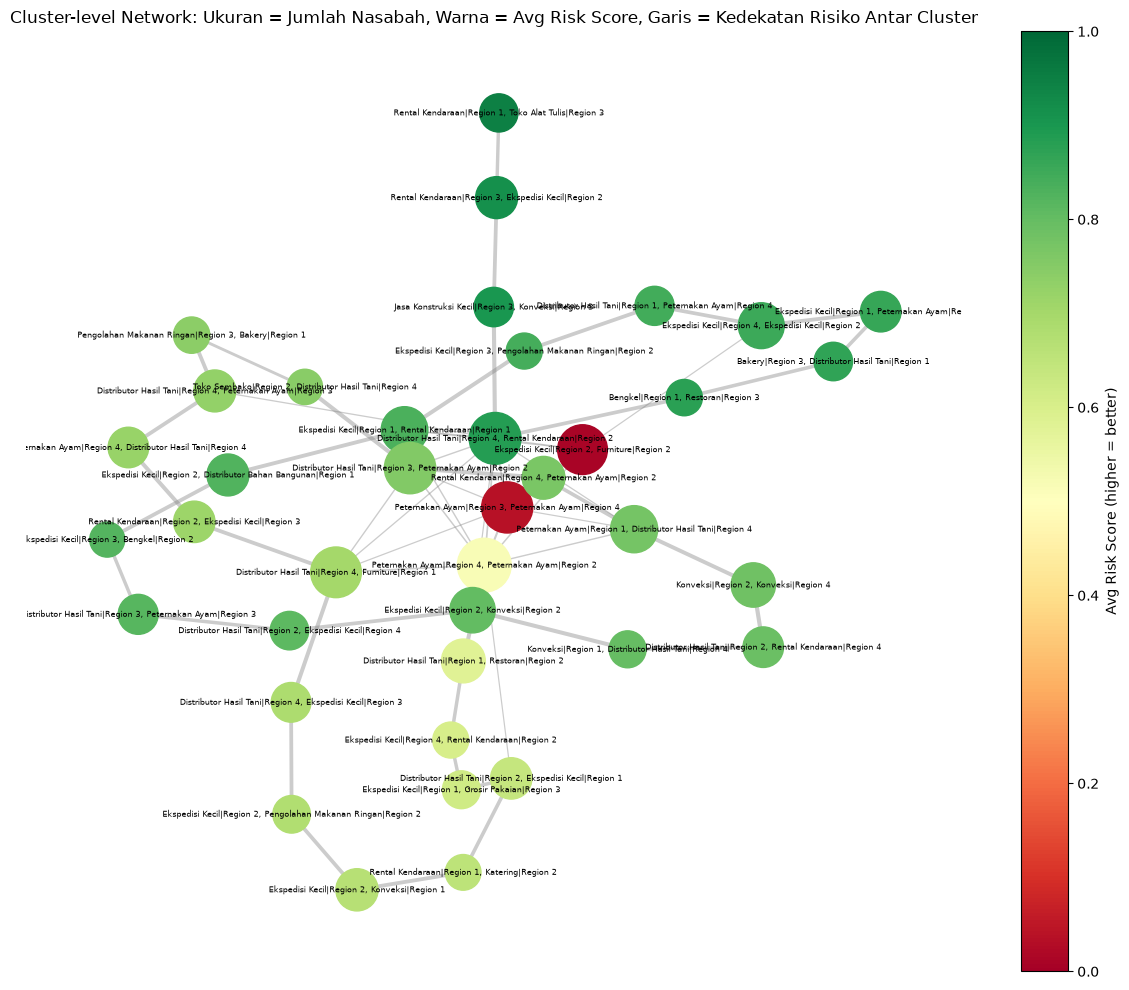

In [10]:
fig, ax = plt.subplots(figsize=(12, 10))

pos = nx.spring_layout(CG, seed=42, k=1.2, weight="weight")

sizes = [CG.nodes[n]["size"] * 12 for n in CG.nodes]
scores = [CG.nodes[n]["score"] for n in CG.nodes]
edge_weights = [CG[u][v]["weight"] for u, v in CG.edges]
max_w = max(edge_weights) if edge_weights else 1

nx.draw_networkx_edges(
    CG, pos, width=[3 * (w / max_w) for w in edge_weights], edge_color="gray", alpha=0.4, ax=ax
)
nodes_drawn = nx.draw_networkx_nodes(
    CG, pos, node_size=sizes, node_color=scores, cmap=cm.RdYlGn, vmin=0, vmax=1, ax=ax
)
nx.draw_networkx_labels(
    CG, pos,
    labels={n: cluster_summary_plot.loc[cluster_summary_plot["cluster_id"] == n, "top_segments"].values[0]
            for n in CG.nodes},
    font_size=6, ax=ax
)

plt.colorbar(nodes_drawn, ax=ax, label="Avg Risk Score (higher = better)")
ax.set_title("Cluster-level Network: Ukuran = Jumlah Nasabah, Warna = Avg Risk Score, Garis = Kedekatan Risiko Antar Cluster")
ax.axis("off")
plt.tight_layout()
plt.show()

## Tahap 7 — Generate Insight / Narasi Otomatis

Sekarang mencakup dua jenis insight: konsentrasi risiko per cluster (seperti sebelumnya), **plus**
pasangan cluster yang paling erat terhubung — segmen mana yang risikonya "menyatu" meski industrinya
berbeda.

In [11]:
insights = []

top_risk = cluster_summary.head(3)
for cid, row in top_risk.iterrows():
    insights.append(
        f"- Cluster (id={cid}, dominan: {row['top_segments']}, n={int(row['n_nasabah'])} nasabah) "
        f"punya konsentrasi risiko tertinggi: {row['low_score_share']*100:.1f}% nasabah di bawah "
        f"ambang skor {LOW_SCORE_THRESHOLD}, rata-rata risk_score {row['avg_score']:.2f}."
    )

inconsistent = cluster_summary[cluster_summary["n_nasabah"] >= 10].sort_values("std_score", ascending=False).head(3)
for cid, row in inconsistent.iterrows():
    insights.append(
        f"- Cluster (id={cid}, dominan: {row['top_segments']}) menunjukkan variasi risk_score tinggi "
        f"(std={row['std_score']:.2f}) — indikasi perlu review konsistensi kriteria scoring."
    )

print("Insight konsentrasi & inkonsistensi risiko:")
print("\n".join(insights))

print("\nPasangan cluster paling erat terhubung secara risiko (top 5):")
for (cu, cv), w in sorted(cluster_edge_weight.items(), key=lambda x: -x[1])[:5]:
    seg_u = cluster_summary.loc[cu, "top_segments"] if cu in cluster_summary.index else "?"
    seg_v = cluster_summary.loc[cv, "top_segments"] if cv in cluster_summary.index else "?"
    print(f"- Cluster {cu} ({seg_u})  <->  Cluster {cv} ({seg_v})  |  kedekatan={w:.0f}")

Insight konsentrasi & inkonsistensi risiko:
- Cluster (id=1, dominan: Ekspedisi Kecil|Region 2, Furniture|Region 2, n=107 nasabah) punya konsentrasi risiko tertinggi: 100.0% nasabah di bawah ambang skor 0.4, rata-rata risk_score 0.01.
- Cluster (id=35, dominan: Peternakan Ayam|Region 3, Peternakan Ayam|Region 4, n=113 nasabah) punya konsentrasi risiko tertinggi: 100.0% nasabah di bawah ambang skor 0.4, rata-rata risk_score 0.04.
- Cluster (id=25, dominan: Peternakan Ayam|Region 4, Peternakan Ayam|Region 2, n=125 nasabah) punya konsentrasi risiko tertinggi: 3.2% nasabah di bawah ambang skor 0.4, rata-rata risk_score 0.52.
- Cluster (id=25, dominan: Peternakan Ayam|Region 4, Peternakan Ayam|Region 2) menunjukkan variasi risk_score tinggi (std=0.04) — indikasi perlu review konsistensi kriteria scoring.
- Cluster (id=23, dominan: Rental Kendaraan|Region 1, Toko Alat Tulis|Region 3) menunjukkan variasi risk_score tinggi (std=0.01) — indikasi perlu review konsistensi kriteria scoring.
- Clus

## Tahap 8 — Export untuk Dashboard

Export ringkasan cluster & edge antar-cluster ke `data/processed/` supaya bisa divisualisasikan di
halaman Streamlit (`pages_v2/00_Overview_Premium.py`, section **Industry Intelligence**) tanpa perlu
re-run Louvain di dalam app tiap kali halaman dibuka. Semua 666 pasangan cluster (bukan cuma top 60
yang digambar di Tahap 6) diekspor supaya app bisa atur sendiri ambang tampilnya.

In [12]:
import os

OUT_DIR = "../data/processed"
os.makedirs(OUT_DIR, exist_ok=True)

cluster_nodes_export = cluster_summary_plot.copy()
cluster_nodes_export.to_csv(os.path.join(OUT_DIR, "industry_cluster_nodes.csv"), index=False)

cluster_edges_export = pd.DataFrame(
    [(cu, cv, w) for (cu, cv), w in cluster_edge_weight.items()],
    columns=["cluster_a", "cluster_b", "weight"],
)
cluster_edges_export.to_csv(os.path.join(OUT_DIR, "industry_cluster_edges.csv"), index=False)

representatives_df.to_csv(os.path.join(OUT_DIR, "industry_cluster_representatives.csv"), index=False)

print("Tersimpan:")
print(" -", os.path.join(OUT_DIR, "industry_cluster_nodes.csv"), cluster_nodes_export.shape)
print(" -", os.path.join(OUT_DIR, "industry_cluster_edges.csv"), cluster_edges_export.shape)
print(" -", os.path.join(OUT_DIR, "industry_cluster_representatives.csv"), representatives_df.shape)

Tersimpan:
 - ../data/processed\industry_cluster_nodes.csv (39, 6)
 - ../data/processed\industry_cluster_edges.csv (741, 3)
 - ../data/processed\industry_cluster_representatives.csv (39, 6)


## Penutup & Next Steps

- Perbedaan utama dari v1: cluster sekarang bisa **memotong batas sub_industry/region** kalau
  risk_score-nya memang mirip, dan visualisasi punya **connector nyata** antar cluster — bukan lagi
  sekadar bubble chart.
- `K_NEIGHBORS` (jumlah tetangga di Graph B) dan `TOP_N_EDGES` (jumlah edge yang ditampilkan) bisa
  disesuaikan: makin besar `K_NEIGHBORS`, makin banyak jembatan lintas-segmen yang terbentuk —
  coba beberapa nilai dan lihat mana yang paling masuk akal untuk cerita insight-nya.
- Untuk use case **RM concentration/collusion risk** (`rm_master.csv`), masih perlu augmentasi data
  seperti dibahas sebelumnya — atribut sensitif (alamat/agunan/no HP) di data saat ini unik per
  nasabah sehingga belum ada pola untuk dideteksi.